#### Regularization

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
dataset = pd.read_excel("../../datasets/houseprice.xlsx")
dataset.head(5)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,3,2.0,1800,5000,1,0,0,3,1200,600,1990,0,450000
1,4,3.5,2500,7200,2,1,2,4,2000,500,2005,2015,850000
2,2,1.0,980,3000,1,0,0,2,980,0,1965,0,320000
3,5,4.0,3200,10000,2,1,3,5,2500,700,2010,2020,1200000
4,3,2.5,2100,6000,2,0,1,3,1500,600,1985,0,560000


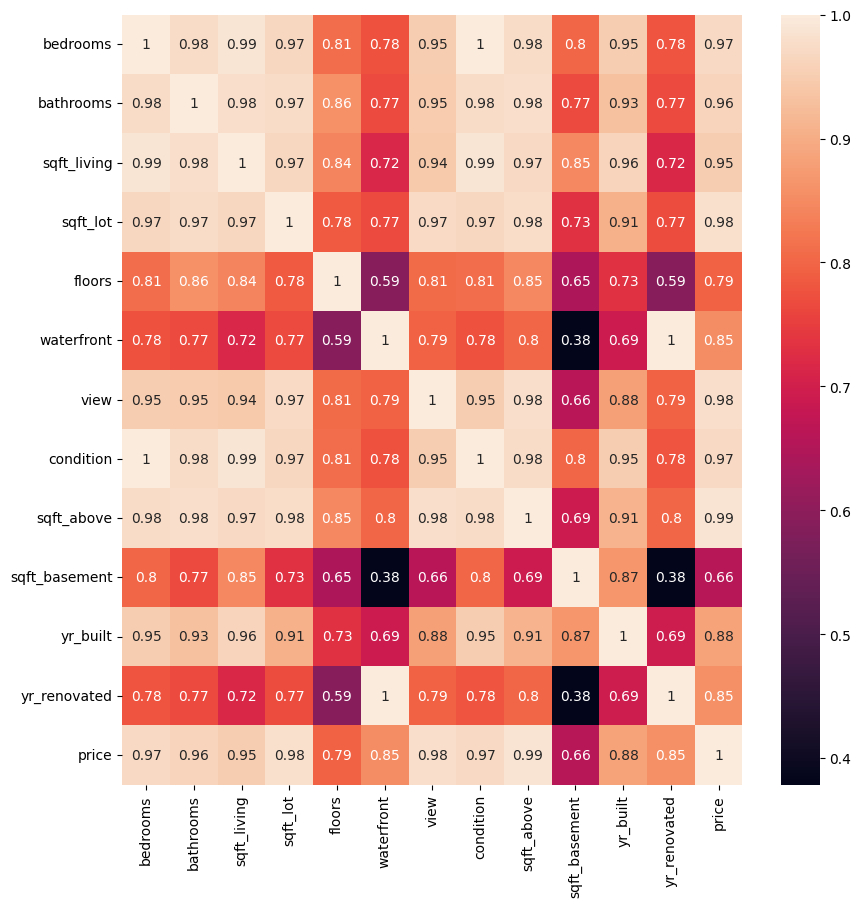

In [3]:
plt.figure(figsize=(10,10))
sns.heatmap(data=dataset.corr(), annot=True)
plt.show()

In [4]:
x = dataset.iloc[:, :-1]
y = dataset["price"]

In [5]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns=x.columns)

In [6]:
x_train, x_test, y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

### LinearRegression

In [9]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)*100

99.96199020631136

In [10]:
lr.coef_

array([ 6.62410414e+04, -3.77629281e+04,  2.65805700e+04,  1.38770327e+05,
        1.35819679e+04, -9.12677408e+06,  5.14333150e+03,  6.62410414e+04,
        5.30011199e+04, -3.67203643e+04, -2.02749613e+04,  9.18715219e+06])

In [11]:
print(mean_squared_error(y_test, lr.predict(x_test)))
print(mean_absolute_error(y_test, lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, lr.predict(x_test))))

14006608.974263191
3159.452020564582
3742.540443904807


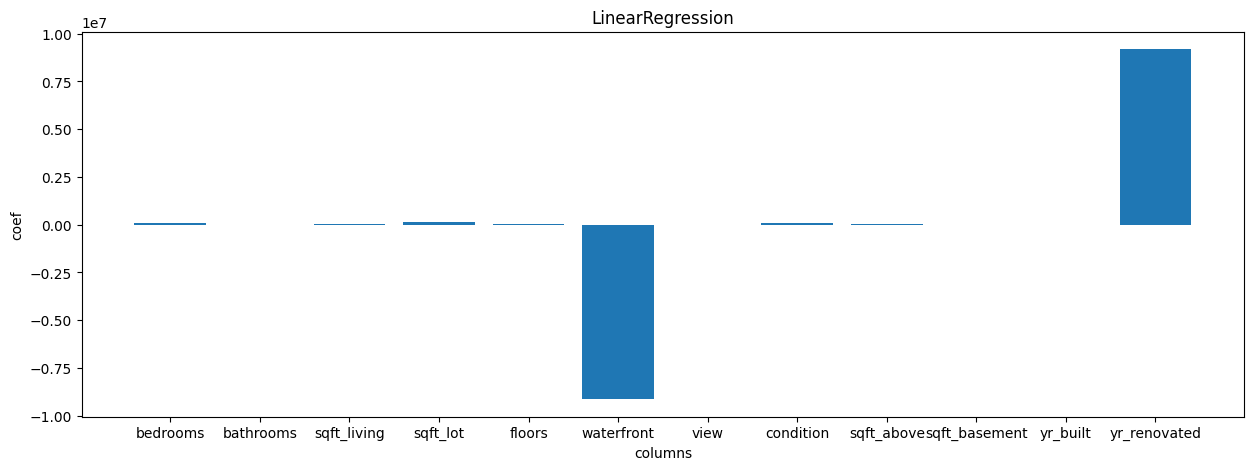

In [12]:
plt.figure(figsize=(15,5))
plt.bar(x.columns, lr.coef_)
plt.title("LinearRegression")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

### Lasso

In [13]:
la = Lasso(alpha=0.01)
la.fit(x_train, y_train)
la.score(x_test, y_test)*100

99.24995801569472

In [14]:
print(mean_squared_error(y_test, la.predict(x_test)))
print(mean_absolute_error(y_test, la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, la.predict(x_test))))

276390471.21649706
10501.707572549349
16624.9953749316


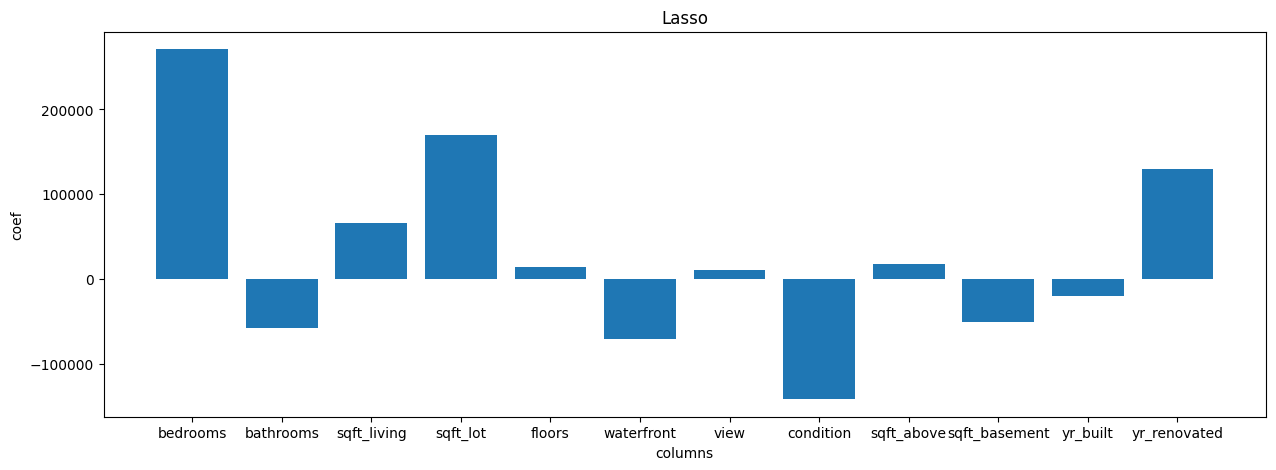

In [15]:
plt.figure(figsize=(15,5))
plt.bar(x.columns, la.coef_)
plt.title("Lasso")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

### Ridge

In [16]:
ri = Ridge(alpha = 10)
ri.fit(x_train, y_train)
ri.score(x_test, y_test)*100

89.81051037042764

In [17]:
print(mean_squared_error(y_test, ri.predict(x_test)))
print(mean_absolute_error(y_test, ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, ri.predict(x_test))))

3754826928.4974117
50090.19848822396
61276.64260138125


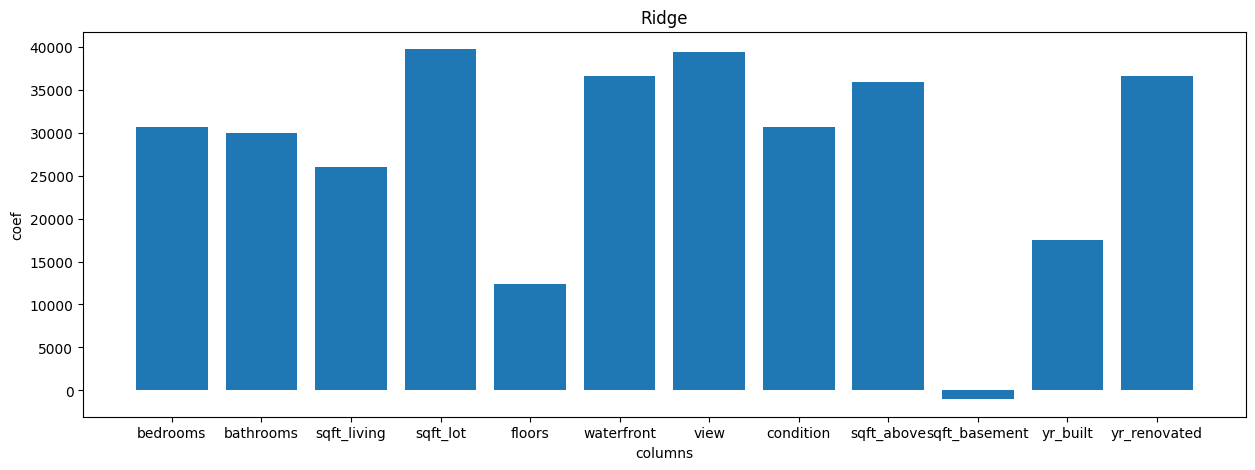

In [18]:
plt.figure(figsize=(15,5))
plt.bar(x.columns, ri.coef_)
plt.title("Ridge")
plt.xlabel("columns")
plt.ylabel("coef")
plt.show()

In [19]:
df = pd.DataFrame({"col_name": x.columns, "LinearRegression":lr.coef_, "Lasso": la.coef_, "Ridge": ri.coef_})
df

,col_name,LinearRegression,Lasso,Ridge
0,bedrooms,6.624104e+04,271133.671657,30643.678872
1,bathrooms,-3.776293e+04,-58533.463365,30015.748059
2,sqft_living,2.658057e+04,65486.748504,26055.886500
3,sqft_lot,1.387703e+05,170338.704903,39743.447110
4,floors,1.358197e+04,13570.420673,12404.542942
5,waterfront,-9.126774e+06,-71424.613172,36605.376880
6,view,5.143331e+03,10885.607229,39358.681002
7,condition,6.624104e+04,-141836.716338,30643.678872
8,sqft_above,5.300112e+04,17592.006100,35869.801818
9,sqft_basement,-3.672036e+04,-51109.681802,-1024.276743
